# SimBench Simulation

In [1]:
import pandapower as pp
import pyomo.environ as pe
import pyomo.opt as po
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandapower.plotting as pplot
import datetime
import pickle
import simbench
import scienceplots
import json
import os
import sys

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
# Add Model_Build_Manifest to path (adjust this path as needed)
# If Model_Build_Manifest is in the current directory:
sys.path.insert(0, './Model_Build_Manifest')

# Import from Model_Build_Manifest
from simulator import ManifestFactory, ModelData, CONSTRAINT_LIBRARY
from controller import ModelAssembler, MPCController, SolverConfig

In [3]:
class EnetGridModel:
    """
    Compatibility wrapper that provides the same interface as the original Enet.elec_grid.EnetGridModel
    but uses Model_Build_Manifest internally.

    This class bridges the gap between the original notebook interface and the new
    Model_Build_Manifest framework without modifying the framework code.
    """

    def __init__(self, Enet, config_path="./elec_simbench_config.json"):
        """
        Initialize the grid model.

        Args:
            Enet: Pandapower network object
            config_path: Path to configuration JSON file
        """
        self.Enet_original = Enet
        self.config_path = config_path

        # Load configuration
        with open(config_path, 'r') as f:
            self.config = json.load(f)

        # Store original network data for time series
        self._store_timeseries_data()

        # Current time step state
        self.current_step = 0
        self.current_prefix = 0

        # Results storage
        self.results = None
        self.model = None
        self.mpc = None

        # Storage state tracking (for MPC)
        self.storage_soc = {}
        if hasattr(Enet, 'storage') and not Enet.storage.empty:
            for idx in Enet.storage.index:
                self.storage_soc[idx] = Enet.storage.loc[idx, 'soc_percent'] / 100.0 * Enet.storage.loc[idx, 'max_e_mwh']

    def _store_timeseries_data(self):
        """Store time series data from the network."""
        self.profiles_load_p = None
        self.profiles_load_q = None
        self.profiles_pv_p = None

        if 'profiles_load_p' in self.Enet_original.keys():
            self.profiles_load_p = self.Enet_original['profiles_load_p']
        if 'profiles_load_q' in self.Enet_original.keys():
            self.profiles_load_q = self.Enet_original['profiles_load_q']
        if 'profiles_pv_p' in self.Enet_original.keys():
            self.profiles_pv_p = self.Enet_original['profiles_pv_p']

    def assgin_parameters_values(self, step, prefix=0):
        """
        Assign parameter values for a given time step and scenario.

        This method updates the Pandapower network with the time series values
        before building the optimization model.

        Args:
            step: Time step index
            prefix: Scenario index (for different profiles)
        """
        self.current_step = step
        self.current_prefix = prefix

        print(f"Optimization is performed with time series, the time series of pandapower grid will be loaded.")

        # Create a fresh copy of the network
        self.Enet = pp.pandapowerNet(self.Enet_original)

        # Update load values from profiles
        if self.profiles_load_p is not None and len(self.profiles_load_p) > prefix:
            for i, idx in enumerate(self.Enet.load.index):
                if i < len(self.profiles_load_p[prefix]):
                    self.Enet.load.loc[idx, 'p_mw'] = self.profiles_load_p[prefix][i][step]

        if self.profiles_load_q is not None and len(self.profiles_load_q) > prefix:
            for i, idx in enumerate(self.Enet.load.index):
                if i < len(self.profiles_load_q[prefix]):
                    self.Enet.load.loc[idx, 'q_mvar'] = self.profiles_load_q[prefix][i][step]

        # Update sgen (PV) values from profiles
        if self.profiles_pv_p is not None and len(self.profiles_pv_p) > prefix:
            for i, idx in enumerate(self.Enet.sgen.index):
                if i < len(self.profiles_pv_p[prefix]):
                    self.Enet.sgen.loc[idx, 'p_mw'] = self.profiles_pv_p[prefix][i][step]

        # Update storage SOC if tracking storage
        if hasattr(self.Enet, 'storage') and not self.Enet.storage.empty:
            for idx in self.Enet.storage.index:
                if idx in self.storage_soc:
                    # Calculate SOC percentage from stored energy
                    max_e = self.Enet.storage.loc[idx, 'max_e_mwh']
                    if max_e > 0:
                        self.Enet.storage.loc[idx, 'soc_percent'] = (self.storage_soc[idx] / max_e) * 100.0

    def run_opt(self):
        """
        Run the optimization using Model_Build_Manifest framework.
        """
        # Step 1: Create ModelData (validates and prepares network)
        model_data = ModelData(self.Enet, self.config)

        # Step 2: Create manifest
        manifest_factory = ManifestFactory(model_data)
        manifest = manifest_factory.create_manifest()

        # Step 3: Create model assembler with constraint library
        assembler = ModelAssembler(CONSTRAINT_LIBRARY)
        assembler.register_manifest(manifest)

        # Step 4: Create solver configuration
        # Note: verbose and tee are SolverConfig attributes, NOT ipopt options
        raw_solver_options = self.config.get('solver_options', {})
        # Filter out non-ipopt options
        ipopt_options = {k: v for k, v in raw_solver_options.items()
                         if k not in ['verbose', 'tee']}
        # Add default ipopt options if not specified
        if 'tol' not in ipopt_options:
            ipopt_options['tol'] = 1e-8
        if 'max_iter' not in ipopt_options:
            ipopt_options['max_iter'] = 1000

        solver_config = SolverConfig(
            solver_name=self.config.get('solver', 'ipopt'),
            options=ipopt_options,
            verbose=raw_solver_options.get('verbose', True),
            tee=raw_solver_options.get('tee', False)
        )

        # Step 5: Create MPC controller and build model
        self.mpc = MPCController(assembler, self.config, solver_config)
        self.model = self.mpc.build_model()

        # Step 6: Set objective function
        objective_type = self.config.get('objective', 'quadratic_exchange')
        self.mpc.set_objective(objective_type, model_data.Enet)

        # Step 7: Fix boundary conditions
        self.mpc.fix_slack_nodes()
        self._fix_loads_and_generators(model_data.Enet)

        # Step 8: Solve
        try:
            results = self.mpc.solve()
            self.results = self.mpc.extract_results(model_data.Enet)
            print(f"Convergence: {results.solver.termination_condition.value} ")
        except Exception as e:
            print(f"Solver error: {e}")
            self.results = None

        # Store the processed Enet for result extraction
        self._processed_Enet = model_data.Enet

    def _fix_loads_and_generators(self, Enet):
        """Fix load and generator values based on current time step data."""
        model = self.model

        # Fix loads (using indices from pq_nodes set which are load indices)
        if not Enet.load.empty:
            for load_idx in model.pq_nodes:
                if load_idx in Enet.load.index:
                    p_val = Enet.load.loc[load_idx, 'p_mw']
                    q_val = Enet.load.loc[load_idx, 'q_mvar']
                    model.Pload[load_idx, :].fix(p_val)
                    model.Qload[load_idx, :].fix(q_val)

        # Fix sgen (static generators like PV)
        if not Enet.sgen.empty:
            for sgen_idx in model.sgen_nodes:
                if sgen_idx in Enet.sgen.index:
                    p_val = Enet.sgen.loc[sgen_idx, 'p_mw']
                    q_val = Enet.sgen.loc[sgen_idx, 'q_mvar']
                    model.Psgen[sgen_idx, :].fix(p_val)
                    model.Qsgen[sgen_idx, :].fix(q_val)

        # Fix gen (conventional generators)
        if not Enet.gen.empty:
            for gen_idx in model.generator_nodes:
                if gen_idx in Enet.gen.index:
                    if 'p_mw' in Enet.gen.columns:
                        model.Pgen[gen_idx, :].fix(Enet.gen.loc[gen_idx, 'p_mw'])
                    if 'q_mvar' in Enet.gen.columns:
                        model.Qgen[gen_idx, :].fix(Enet.gen.loc[gen_idx, 'q_mvar'])

    def extract_results(self, save_file=None):
        """
        Extract optimization results.

        Args:
            save_file: Optional path to save results as pickle file

        Returns:
            Tuple of (res_bus, res_line, res_obj_fcn)
        """
        if self.results is None:
            return None, None, None

        # Create result DataFrames matching original interface
        Enet = self._processed_Enet

        # Bus results
        res_bus = pd.DataFrame({
            'vm_pu': self.results['V_pu'][:, 0],
            'va_degree': np.degrees(self.results['Theta_rad'][:, 0]),
            'p_mw': self.results['P_mw'][:, 0],
            'q_mvar': self.results['Q_mvar'][:, 0]
        })

        # Line results
        n_edges = self.results['pf_mw'].shape[0]
        res_line = pd.DataFrame({
            'p_from_mw': self.results['pf_mw'][:, 0],
            'q_from_mvar': self.results['qf_mvar'][:, 0],
            'p_to_mw': self.results['pt_mw'][:, 0],
            'q_to_mvar': self.results['qt_mvar'][:, 0]
        })

        # Objective function value
        res_obj_fcn = self.results['objective']

        # Save results if requested
        if save_file is not None:
            os.makedirs(os.path.dirname(save_file), exist_ok=True)
            with open(save_file, 'wb') as f:
                pickle.dump({
                    'res_bus': res_bus,
                    'res_line': res_line,
                    'res_obj_fcn': res_obj_fcn,
                    'raw_results': self.results,
                    'step': self.current_step,
                    'prefix': self.current_prefix
                }, f)

        return res_bus, res_line, res_obj_fcn

    def update_storages(self):
        """
        Update storage state-of-charge for MPC rolling horizon.

        This method should be called after each optimization step to
        update the storage energy level for the next time step.
        """
        if self.results is None:
            return

        if not hasattr(self._processed_Enet, 'storage') or self._processed_Enet.storage.empty:
            return

        # Update storage SOC based on optimization results
        # Note: This is a simplified update - the actual implementation may need
        # to extract storage power from the model if available
        dt_min = self.config.get('dt_min', 15)
        dt_hours = dt_min / 60.0

        if hasattr(self.model, 'Psto'):
            for idx in self._processed_Enet.storage.index:
                if idx in self.storage_soc:
                    # Get storage power from model (if available)
                    try:
                        p_sto = pe.value(self.model.Psto[idx, 0])
                        # Update energy: E_new = E_old + P * dt
                        self.storage_soc[idx] += p_sto * dt_hours
                        # Clip to bounds
                        max_e = self._processed_Enet.storage.loc[idx, 'max_e_mwh']
                        min_e = self._processed_Enet.storage.loc[idx, 'min_e_mwh']
                        self.storage_soc[idx] = np.clip(self.storage_soc[idx], min_e, max_e)
                    except:
                        pass  # Storage variable not in model

In [4]:
code = '1-LV-rural1--1-sw'
Enet = simbench.get_simbench_net(code)
# Enet.bus_geodata.loc[0, 'x'] = Enet.bus_geodata.loc[1, 'x'] - 0.0013
# Enet.bus_geodata.loc[0, 'y'] = Enet.bus_geodata.loc[1, 'y'] + 0.001
# 1. Add the PV-devices
Enet.sgen = pd.concat([Enet.sgen, Enet.sgen[0:4]], ignore_index=True)

Enet.sgen.loc[8, "name"] = "LV1.101 SGen 9"
Enet.sgen.loc[9, "name"] = "LV1.101 SGen 10"
Enet.sgen.loc[10, "name"] = "LV1.101 SGen 11"
Enet.sgen.loc[11, "name"] = "LV1.101 SGen 12"

Enet.sgen.loc[8, "bus"] = 12
Enet.sgen.loc[9, "bus"] = 14
Enet.sgen.loc[10, "bus"] = 6
Enet.sgen.loc[11, "bus"] = 9

# 2. Add the constraints for the PV-devices
Enet.storage["max_p_mw"] = -Enet.storage["min_p_mw"]

Enet.ext_grid['vm_pu'] = 1

In [5]:
# --- 辅助函数：检查索引是否受影响 ---
def is_index_affected(index, affected_idx):
    """Checks if the current index is in the affected index list/int."""
    if isinstance(affected_idx, int):
        return index == affected_idx
    elif isinstance(affected_idx, (list, np.ndarray)):
        return index in affected_idx
    return False

In [6]:
# --- 初始化三层列表结构 ---
profiles_load_p = [[], []]
profiles_load_q = [[], []]
profiles_pv_p = [[], []]

In [7]:
# --- 扰动参数设定 (Disturbance Parameters Setting) ---
TIME_SLICE = slice(96*5, 96*7)

T_START_GD = 48   # 发电跌落开始时刻 (例如：第 5 天的第 80 步)
DUR_GD = 8             # 持续 8 步
GD_FACTOR = 1.5        # 发电目标值

GD_AFFECTED_PV_IDX = [0,8,9,10,7] #

In [8]:
# --- 构建负荷曲线 (Build Load Profiles) ---
for i, profile in enumerate(Enet.load.profile.values):
    # 基础曲线 (Base Profile)
    p0_p = Enet.profiles["load"][profile + "_pload"].values[TIME_SLICE] * Enet.load["p_mw"][i]
    p0_q = Enet.profiles["load"][profile + "_qload"].values[TIME_SLICE] * Enet.load["q_mvar"][i]

    # P0: 原始曲线
    profiles_load_p[0].append(p0_p.copy())
    profiles_load_q[0].append(p0_q.copy())

    # S2
    p1_p = p0_p.copy()
    p1_q = p0_q.copy()

    profiles_load_p[1].append(p0_p.copy())
    profiles_load_q[1].append(p0_q.copy())


# --- 构建光伏曲线 (Build PV Profiles) ---
for i, profile in enumerate(Enet.sgen.profile.values):
    # 基础曲线 (Base Profile)
    p0_pv = Enet.profiles["renewables"][profile].values[TIME_SLICE] * Enet.sgen["p_mw"][i]

    # P0: 原始曲线
    profiles_pv_p[0].append(p0_pv.copy())

    # S2
    p2_pv = p0_pv.copy()

    if is_index_affected(i, GD_AFFECTED_PV_IDX):
        # 骤降至 X% 额定值 (X=0)
        p2_pv[T_START_GD : T_START_GD + DUR_GD] = GD_FACTOR * p2_pv[T_START_GD : T_START_GD + DUR_GD]

    profiles_pv_p[1].append(p2_pv)

In [9]:
Enet.sgen

,name,bus,p_mw,q_mvar,sn_mva,scaling,in_service,type,current_source,slack_weight,max_p_mw,min_p_mw,max_q_mvar,voltLvl,profile,min_q_mvar,subnet,phys_type
0,LV1.101 SGen 1,7,0.0400,0.0,0.0400,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV5,NaN,LV1.101,RES
1,LV1.101 SGen 2,11,0.0784,0.0,0.0784,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV8,NaN,LV1.101,RES
2,LV1.101 SGen 4,8,0.0190,0.0,0.0190,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV6,NaN,LV1.101,RES
3,LV1.101 SGen 3,13,0.0230,0.0,0.0230,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV5,NaN,LV1.101,RES
4,LV1.101 SGen 5,3,0.0489,0.0,0.0489,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV8,NaN,LV1.101,RES
5,LV1.101 SGen 6,1,0.1172,0.0,0.1172,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV8,NaN,LV1.101,RES
6,LV1.101 SGen 7,2,0.0245,0.0,0.0245,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV6,NaN,LV1.101,RES
7,LV1.101 SGen 8,5,0.1172,0.0,0.1172,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV6,NaN,LV1.101,RES
8,LV1.101 SGen 9,12,0.0400,0.0,0.0400,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV5,NaN,LV1.101,RES
9,LV1.101 SGen 10,14,0.0784,0.0,0.0784,1.0,True,PV,NaN,NaN,NaN,NaN,NaN,7,PV8,NaN,LV1.101,RES


In [10]:
Enet.load

,name,bus,p_mw,q_mvar,const_z_percent,const_i_percent,sn_mva,scaling,in_service,type,max_p_mw,min_p_mw,max_q_mvar,voltLvl,profile,min_q_mvar,subnet
0,LV1.101 Load 1,10,0.0060,0.0024,0.0,0.0,0.0065,1.0,True,NaN,NaN,NaN,NaN,7,L2-A,NaN,LV1.101
1,LV1.101 Load 2,8,0.0030,0.0012,0.0,0.0,0.0032,1.0,True,NaN,NaN,NaN,NaN,7,H0-C,NaN,LV1.101
2,LV1.101 Load 3,14,0.0050,0.0020,0.0,0.0,0.0054,1.0,True,NaN,NaN,NaN,NaN,7,L1-A,NaN,LV1.101
3,LV1.101 Load 4,13,0.0020,0.0008,0.0,0.0,0.0022,1.0,True,NaN,NaN,NaN,NaN,7,H0-B,NaN,LV1.101
4,LV1.101 Load 5,9,0.0040,0.0016,0.0,0.0,0.0043,1.0,True,NaN,NaN,NaN,NaN,7,L2-A,NaN,LV1.101
5,LV1.101 Load 6,6,0.0030,0.0012,0.0,0.0,0.0032,1.0,True,NaN,NaN,NaN,NaN,7,L1-A,NaN,LV1.101
6,LV1.101 Load 7,3,0.0080,0.0031,0.0,0.0,0.0086,1.0,True,NaN,NaN,NaN,NaN,7,L1-A,NaN,LV1.101
7,LV1.101 Load 8,1,0.0139,0.0055,0.0,0.0,0.0149,1.0,True,NaN,NaN,NaN,NaN,7,L2-A,NaN,LV1.101
8,LV1.101 Load 9,7,0.0030,0.0012,0.0,0.0,0.0032,1.0,True,NaN,NaN,NaN,NaN,7,L2-A,NaN,LV1.101
9,LV1.101 Load 10,12,0.0120,0.0047,0.0,0.0,0.0129,1.0,True,NaN,NaN,NaN,NaN,7,L1-A,NaN,LV1.101


In [11]:
Enet.storage

,name,bus,p_mw,q_mvar,sn_mva,soc_percent,min_e_mwh,max_e_mwh,scaling,in_service,type,max_p_mw,min_p_mw,efficiency_percent,self-discharge_percent_per_day,max_q_mvar,voltLvl,profile,min_q_mvar,subnet
0,LV1.101 Storage 1,12,-0.0734,0.0,0.0734,0.0,0.0,0.1467,1.0,True,PV_Storage,0.073352,-0.073352,0.95,0.13,0.073352,7,Storage_PV8_L1-A,-0.073352,LV1.101
1,LV1.101 Storage 2,9,-0.0335,0.0,0.0335,0.0,0.0,0.0670,1.0,True,PV_Storage,0.033488,-0.033488,0.95,0.13,0.033488,7,Storage_PV5_L2-A,-0.033488,LV1.101
2,LV1.101 Storage 3,14,-0.0306,0.0,0.0306,0.0,0.0,0.0611,1.0,True,PV_Storage,0.030563,-0.030563,0.95,0.13,0.030563,7,Storage_PV5_L1-A,-0.030563,LV1.101
3,LV1.101 Storage 4,6,-0.0183,0.0,0.0183,0.0,0.0,0.0367,1.0,True,PV_Storage,0.018338,-0.018338,0.95,0.13,0.018338,7,Storage_PV8_L1-A,-0.018338,LV1.101


In [12]:
Enet["profiles_load_p"] = np.array(profiles_load_p)
Enet["profiles_load_q"] = np.array(profiles_load_q)
Enet["profiles_pv_p"] = np.array(profiles_pv_p)
for key, df in Enet.items():
    if isinstance(df, pd.DataFrame):
        Enet[key] = df.round(4)

In [13]:
Enet_backup = pp.pandapowerNet(Enet)

In [14]:
# Create results directory
os.makedirs("./results/S3", exist_ok=True)

with open(f"./results/S3/Enet.pkl", 'wb') as f:
    pickle.dump(Enet_backup, f)

In [15]:
simulation_step = 1

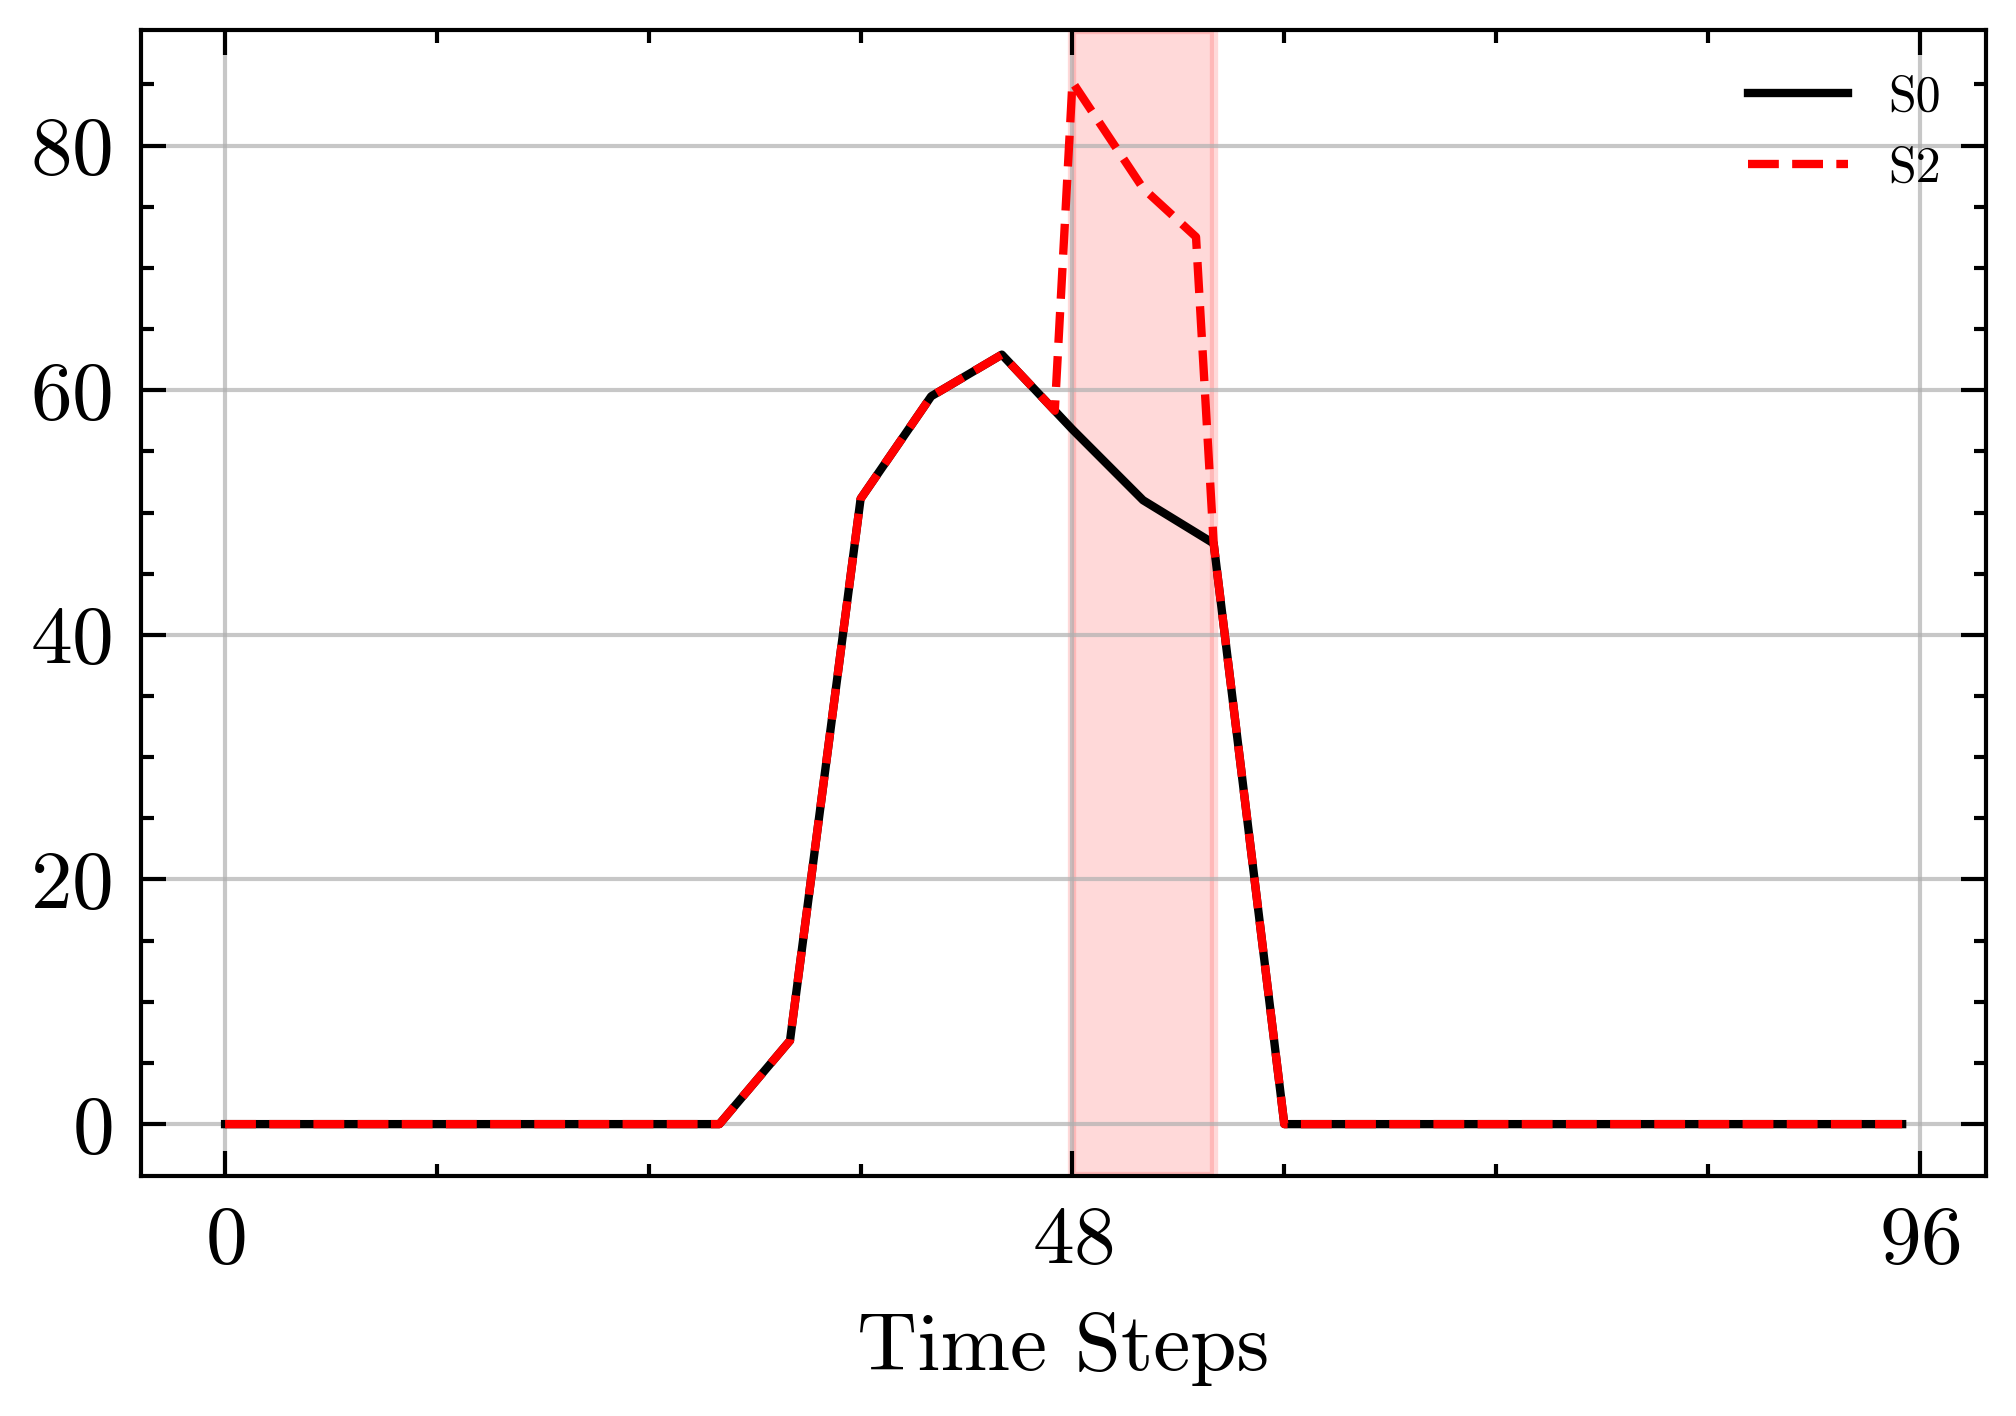

In [16]:
plt.style.use(['science', 'ieee', "no-latex"])
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5))
T_START = 48
DURATION = 8

ax.plot(np.array(Enet["profiles_pv_p"][0])[GD_AFFECTED_PV_IDX, :96].sum(axis=0) * 1000, label="S0")
ax.plot(np.array(Enet["profiles_pv_p"][1])[GD_AFFECTED_PV_IDX, :96].sum(axis=0) * 1000, label="S2")
ax.grid(alpha=0.7)
ax.set_xticks([0, 48, 96])
ax.legend(fontsize=6)
ax.set_xlabel("Time Steps", fontsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.axvspan(T_START, T_START + DURATION, color='red', alpha=0.15)

plt.tight_layout()
# plt.savefig(f"./pictures/1_scenario.pdf", dpi=300, bbox_inches='tight')

In [17]:
path = f"./results/S3/simulation_maxIA_S0_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
Enet = pp.pandapowerNet(Enet_backup)
Enet.line["max_i_ka"][2] = 0.0404
model = EnetGridModel(Enet, config_path="./data/elec_simbench_config.json")

for j in range(0, simulation_step):
    starttime = datetime.datetime.now()

    model.assgin_parameters_values(j, prefix=0)
    model.run_opt()
    res_bus, res_line, res_obj_fcn = model.extract_results(save_file=f"{path}/model_{j}.pkl")

    model.update_storages()
    endtime = datetime.datetime.now()
    print(endtime-starttime)

Optimization is performed with time series, the time series of pandapower grid will be loaded.
Step Prepare: Validating Enet
Switches in net. Adding small resistance for consistency.
No powerflow solution yet -> running initialization powerflow!
Registered manifest with 15 constraints
Step Build: Creating empty Pyomo model...
  Created SimpleSet 'model.nodes'
  Created SimpleSet 'model.edges'
  Created SimpleSet 'model.lines'
  Created SimpleSet 'model.trafo'
  Created SimpleSet 'model.slack_nodes'
  Created SimpleSet 'model.pq_nodes'
  Created SimpleSet 'model.sgen_nodes'
  Created SimpleSet 'model.generator_nodes'
  Created SimpleSet 'model.storage_nodes'
  Created IndexedSet 'model.mapping_load'
  Created IndexedSet 'model.mapping_sgen'
  Created IndexedSet 'model.mapping_storage'
  Created IndexedSet 'model.mapping_gen'
  Created IndexedSet 'model.mapping_PtG'
  Created IndexedSet 'model.mapping_GtP'
  Created IndexedParam 'model.g_ff'
  Created IndexedParam 'model.b_ff'
  Created 

In [18]:
model.model.pprint()

15 Set Declarations
    edges : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     2 :    Any :   14 : {(10, 3), (14, 12), (7, 4), (9, 2), (8, 11), (11, 10), (4, 8), (12, 7), (6, 14), (4, 1), (2, 4), (13, 9), (5, 6), (0, 4)}
    generator_nodes : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :    -- :    Any :    0 :      {}
    lines : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     2 :    Any :   13 : {(10, 3), (14, 12), (7, 4), (9, 2), (8, 11), (11, 10), (4, 8), (12, 7), (6, 14), (4, 1), (2, 4), (13, 9), (5, 6)}
    mapping_GtP : Size=0, Index=nodes, Ordered=Insertion
        Key : Dimen : Domain : Size : Members
    mapping_PtG : Size=0, Index=nodes, Ordered=Insertion
        Key : Dimen : Domain : Size : Members
    mapping_gen : Size=15, Index=nodes, Ordered=Insertion
        Key : Dimen : Domain : Size : Members
        

In [19]:
path = f"./results/S3/simulation_maxIA_PtG_S0_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
Enet = pp.pandapowerNet(Enet_backup)
Enet.line["max_i_ka"][2] = 0.0404

# ptg
KopplungPtG = dict()
KopplungPtG["max_p_mw"] = dict()
KopplungPtG["bus"] = dict()
KopplungPtG["junction"] = dict()
KopplungPtG["heating_value"] = dict()
KopplungPtG["efficiency"] = dict()

KopplungPtG["max_p_mw"][0] = 0.05
KopplungPtG["bus"][0] = 11
KopplungPtG["junction"][0] = 2
KopplungPtG["heating_value"][0] = 11.55 # in kWh/m3
KopplungPtG["efficiency"][0] = 0.9

Enet["PtG"] = pd.DataFrame(data=KopplungPtG)

model = EnetGridModel(Enet, config_path="./data/elec_simbench_config.json")

for j in range(0, simulation_step):
    starttime = datetime.datetime.now()
    model.assgin_parameters_values(j, prefix=0)

    model.run_opt()
    res_bus, res_line, res_obj_fcn = model.extract_results(save_file=f"{path}/model_{j}.pkl")

    model.update_storages()
    endtime = datetime.datetime.now()
    print(endtime-starttime)

Optimization is performed with time series, the time series of pandapower grid will be loaded.
Step Prepare: Validating Enet
Switches in net. Adding small resistance for consistency.
No powerflow solution yet -> running initialization powerflow!
Registered manifest with 15 constraints
Step Build: Creating empty Pyomo model...
  Created SimpleSet 'model.nodes'
  Created SimpleSet 'model.edges'
  Created SimpleSet 'model.lines'
  Created SimpleSet 'model.trafo'
  Created SimpleSet 'model.slack_nodes'
  Created SimpleSet 'model.pq_nodes'
  Created SimpleSet 'model.sgen_nodes'
  Created SimpleSet 'model.generator_nodes'
  Created SimpleSet 'model.storage_nodes'
  Created SimpleSet 'model.PtG_nodes'
  Created IndexedSet 'model.mapping_load'
  Created IndexedSet 'model.mapping_sgen'
  Created IndexedSet 'model.mapping_storage'
  Created IndexedSet 'model.mapping_gen'
  Created IndexedSet 'model.mapping_PtG'
  Created IndexedSet 'model.mapping_GtP'
  Created IndexedParam 'model.g_ff'
  Create

In [20]:
model.model.pprint()

16 Set Declarations
    PtG_nodes : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    1 :    {0,}
    edges : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     2 :    Any :   14 : {(10, 3), (14, 12), (7, 4), (9, 2), (8, 11), (11, 10), (4, 8), (12, 7), (6, 14), (4, 1), (2, 4), (13, 9), (5, 6), (0, 4)}
    generator_nodes : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :    -- :    Any :    0 :      {}
    lines : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     2 :    Any :   13 : {(10, 3), (14, 12), (7, 4), (9, 2), (8, 11), (11, 10), (4, 8), (12, 7), (6, 14), (4, 1), (2, 4), (13, 9), (5, 6)}
    mapping_GtP : Size=0, Index=nodes, Ordered=Insertion
        Key : Dimen : Domain : Size : Members
    mapping_PtG : Size=15, Index=nodes, Ordered=Insertion
        K

In [21]:
path = f"./results/S3/simulation_maxIA_S2_unknown_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
Enet = pp.pandapowerNet(Enet_backup)
Enet.line["max_i_ka"][2] = 0.0404
model = EnetGridModel(Enet, config_path="./data/elec_simbench_config.json")

for j in range(0, simulation_step):
    starttime = datetime.datetime.now()

    if j<48:
        model.assgin_parameters_values(j, prefix=0)
    elif j>=48:
        model.assgin_parameters_values(j, prefix=1)

    model.run_opt()
    res_bus, res_line, res_obj_fcn = model.extract_results(save_file=f"{path}/model_{j}.pkl")

    model.update_storages()
    endtime = datetime.datetime.now()
    print(endtime-starttime)

Optimization is performed with time series, the time series of pandapower grid will be loaded.
Step Prepare: Validating Enet
Switches in net. Adding small resistance for consistency.
No powerflow solution yet -> running initialization powerflow!
Registered manifest with 15 constraints
Step Build: Creating empty Pyomo model...
  Created SimpleSet 'model.nodes'
  Created SimpleSet 'model.edges'
  Created SimpleSet 'model.lines'
  Created SimpleSet 'model.trafo'
  Created SimpleSet 'model.slack_nodes'
  Created SimpleSet 'model.pq_nodes'
  Created SimpleSet 'model.sgen_nodes'
  Created SimpleSet 'model.generator_nodes'
  Created SimpleSet 'model.storage_nodes'
  Created IndexedSet 'model.mapping_load'
  Created IndexedSet 'model.mapping_sgen'
  Created IndexedSet 'model.mapping_storage'
  Created IndexedSet 'model.mapping_gen'
  Created IndexedSet 'model.mapping_PtG'
  Created IndexedSet 'model.mapping_GtP'
  Created IndexedParam 'model.g_ff'
  Created IndexedParam 'model.b_ff'
  Created 

In [22]:
path = f"./results/S3/simulation_maxIA_PtG_S2_unknown_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
Enet = pp.pandapowerNet(Enet_backup)
Enet.line["max_i_ka"][2] = 0.0404

# ptg
KopplungPtG = dict()
KopplungPtG["max_p_mw"] = dict()
KopplungPtG["bus"] = dict()
KopplungPtG["junction"] = dict()
KopplungPtG["heating_value"] = dict()
KopplungPtG["efficiency"] = dict()

KopplungPtG["max_p_mw"][0] = 0.05
KopplungPtG["bus"][0] = 11
KopplungPtG["junction"][0] = 2
KopplungPtG["heating_value"][0] = 11.55 # in kWh/m3
KopplungPtG["efficiency"][0] = 0.9

Enet["PtG"] = pd.DataFrame(data=KopplungPtG)

model = EnetGridModel(Enet, config_path="./data/elec_simbench_config.json")

for j in range(0, simulation_step):
    starttime = datetime.datetime.now()

    if j<48:
        model.assgin_parameters_values(j, prefix=0)
    elif j>=48:
        model.assgin_parameters_values(j, prefix=1)

    model.run_opt()
    res_bus, res_line, res_obj_fcn = model.extract_results(save_file=f"{path}/model_{j}.pkl")

    model.update_storages()
    endtime = datetime.datetime.now()
    print(endtime-starttime)

Optimization is performed with time series, the time series of pandapower grid will be loaded.
Step Prepare: Validating Enet
Switches in net. Adding small resistance for consistency.
No powerflow solution yet -> running initialization powerflow!
Registered manifest with 15 constraints
Step Build: Creating empty Pyomo model...
  Created SimpleSet 'model.nodes'
  Created SimpleSet 'model.edges'
  Created SimpleSet 'model.lines'
  Created SimpleSet 'model.trafo'
  Created SimpleSet 'model.slack_nodes'
  Created SimpleSet 'model.pq_nodes'
  Created SimpleSet 'model.sgen_nodes'
  Created SimpleSet 'model.generator_nodes'
  Created SimpleSet 'model.storage_nodes'
  Created SimpleSet 'model.PtG_nodes'
  Created IndexedSet 'model.mapping_load'
  Created IndexedSet 'model.mapping_sgen'
  Created IndexedSet 'model.mapping_storage'
  Created IndexedSet 'model.mapping_gen'
  Created IndexedSet 'model.mapping_PtG'
  Created IndexedSet 'model.mapping_GtP'
  Created IndexedParam 'model.g_ff'
  Create